# Strategy performance by market regime: every algo we've built

Expanded from the original 6-sleeve version (`combination.ipynb`'s
MES/MNQ x Donchian/SuperTrend/Bollinger MR) to cover **every
(algo, symbol, candle-interval) combination tested anywhere in
`notebooks/pipelines/breakout/`**, each run with its own best encountered
parameters (including whichever direction that notebook's own comparison
settled on). This directly tests the hypothesis that motivated the whole
regime-detection line of work: different mechanisms have different, and
sometimes *opposite*, natural relationships to market dips/crashes (e.g.
"Keltner and SuperTrend follow the dip down; Donchian does the opposite;
Bollinger MR doesn't care").

**This is descriptive, not a new fitted trading rule.** The regime-gating
*rule* (`combined_with_regime_filter.ipynb`,
`combined_regime_filter_walk_forward.ipynb`) was walk-forward tested and
found to add no significant edge over the plain combined portfolio -- that
finding stands. What this notebook characterizes instead is each
mechanism's own natural regime *fingerprint*: does it make money or lose it
when the market is trending/choppy, high-vol/low-vol -- using the full
history the same way a doctor reads an X-ray, not fitting a forward-looking
threshold on it. See `market-regime-detection.md` memory for the walk-forward
falsification writeup.

**Scope**: every notebook in `notebooks/pipelines/breakout/` is represented
by its single best (direction, parameter) combo, per this notebook's own
findings/holdout -- 26 (algo, symbol, interval) entries in all. Two
directly-superseded notebooks are skipped in favor of their successors
(`supertrend_flip_mes.ipynb` -> `supertrend_flip_long_mes_15m.ipynb`;
`bollinger_vwap_breakout_mes.ipynb`'s 5m pass -> its 15m
direction-compared successor); two MES/MNQ 30m Bollinger MR *short-only*
notebooks are skipped since their own long-vs-short comparison (run inside
the 30m long notebooks) already established long as the better direction.

**One parameter conflict resolved explicitly**: `donchian_breakout_mnq_15m.ipynb`'s
own single-split grid winner was `length=20, risk_reward_ratio=2.0`, but
`combination.ipynb` (and this program's walk-forward, which chose
`length=10` in 9/10 steps) used `length=10, risk_reward_ratio=1.5`. This
notebook uses the walk-forward-preferred `length=10, risk_reward_ratio=1.5`
since it's the more robustly-supported value and matches what's actually
deployed in the combined portfolio.

In [1]:
import datetime as dt
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.indicators import Indicators
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import (
    BollingerMeanReversionStrategy,
    BollingerVwapBreakoutStrategy,
    DonchianBreakoutStrategy,
    KeltnerVwapBreakoutStrategy,
    MacdMeanReversionStrategy,
    OpeningRangeBreakoutStrategy,
    PullbackToMaStrategy,
    StrategyDirection,
    SupportResistanceBreakoutStrategy,
    SuperTrendFlipStrategy,
)
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)

/Users/nick/Documents/www/alphakit/notebooks/pipelines/regime_detection


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


MES_SYMBOL = "MES/USD"
MNQ_SYMBOL = "MNQ/USD"
M2K_SYMBOL = "M2K/USD"
DEPOSIT_USD = 50_000

paths = {
    "MES": _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd)),
    "MNQ": _find_upwards("apps/backtester/datasets/databento/MNQ_c_0_1m.parquet", start=Path(cwd)),
    "M2K": _find_upwards("apps/backtester/datasets/databento/M2K_c_0_1m.parquet", start=Path(cwd)),
}

# Every (symbol, interval) bar series any combo below needs, loaded once and reused.
_t0 = time.time()
bars = {}
for sym, path in paths.items():
    for interval, unit in [(5, "minute"), (15, "minute"), (30, "minute"), (60, "minute"), (1, "day")]:
        bars[(sym, interval, unit)] = load_1m_parquet_resampled(path, interval=interval, unit_of_time=unit)
    print(f"{sym} loaded, {time.time() - _t0:.0f}s elapsed", flush=True)

for sym in paths:
    daily = bars[(sym, 1, "day")]
    print(f"{sym} daily bars: {len(daily)}  span: {daily.index[0]} -> {daily.index[-1]}")

MES loaded, 1s elapsed


MNQ loaded, 2s elapsed


M2K loaded, 2s elapsed


MES daily bars: 2240  span: 2019-05-05 23:59:59.999000 -> 2026-07-12 23:59:59.999000
MNQ daily bars: 2241  span: 2019-05-05 23:59:59.999000 -> 2026-07-13 23:59:59.999000
M2K daily bars: 2241  span: 2019-05-05 23:59:59.999000 -> 2026-07-13 23:59:59.999000


## Regime classification (identical method to `market_regime_detection.ipynb`)

In [3]:
ADX_LENGTH = 14
VOL_LOOKBACK = 20
VOL_PERCENTILE_WINDOW = 252


def compute_regime(ohlc: pd.DataFrame) -> pd.Series:
    """Returns just the regime label Series (daily-indexed), object dtype, NaN during
    warmup -- identical method to market_regime_detection.ipynb / the original
    strategy_performance_by_regime.ipynb."""
    df = ohlc.copy()
    df["adx"] = Indicators.adx(df, length=ADX_LENGTH)
    is_trending = df["adx"] >= 25

    log_returns = np.log(df["close"] / df["close"].shift(1))
    realized_vol = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    vol_percentile = realized_vol.rolling(VOL_PERCENTILE_WINDOW, min_periods=60).rank(pct=True)
    is_high_vol = vol_percentile >= 0.5

    conditions = [
        is_trending & ~is_high_vol,
        is_trending & is_high_vol,
        ~is_trending & ~is_high_vol,
        ~is_trending & is_high_vol,
    ]
    labels = ["Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"]
    regime = pd.Series(np.select(conditions, labels, default="Unclassified"), index=df.index)
    regime[regime == "Unclassified"] = np.nan
    return regime


REGIME_ORDER = ["Trending / Low-Vol", "Trending / High-Vol", "Choppy / Low-Vol", "Choppy / High-Vol"]
regime_by_symbol = {sym: compute_regime(bars[(sym, 1, "day")]) for sym in paths}
for sym, regime in regime_by_symbol.items():
    print(f"{sym} regime coverage: {regime.notna().sum()} / {len(regime)}")

MES regime coverage: 2240 / 2240
MNQ regime coverage: 2241 / 2241
M2K regime coverage: 2241 / 2241


### Tweak: a directional split, to test the dip hypothesis properly

The caveat flagged in the Findings below was real: ADX+vol alone is
**direction-agnostic** -- "Trending / High-Vol" bundles a violent crash
together with a violent melt-up into the same label, so it couldn't fully
test "performs better *during a downward dip*" as originally asked.

Fix: ADX is itself built from two directional-movement components, `+DI`
and `-DI` (pandas_ta's `DMP`/`DMN`) -- comparing them gives trend
*direction*, not just strength, for free from the same underlying
calculation. Splits "Trending" into **Trending Up** / **Trending Down**;
"Choppy" is left undifferentiated (a non-trending market has no reliable
directional read) -- six regimes instead of four:
Trending Up/Low-Vol, Trending Up/High-Vol, Trending Down/Low-Vol,
**Trending Down/High-Vol (the real dip proxy)**, Choppy/Low-Vol,
Choppy/High-Vol.

In [4]:
import pandas_ta


def compute_regime_directional(ohlc: pd.DataFrame) -> pd.Series:
    """Same trend-strength/vol scheme as compute_regime(), but splits Trending into
    Trending Up / Trending Down via +DI vs -DI (pandas_ta's DMP_{length}/DMN_{length} --
    the directional-movement components ADX itself is built from, not a separate
    indicator). Choppy stays undifferentiated -- no reliable directional read when
    there's no trend."""
    df = ohlc.copy()
    adx_result = pandas_ta.adx(df["high"], df["low"], df["close"], length=ADX_LENGTH)
    adx = adx_result[f"ADX_{ADX_LENGTH}"]
    dmp = adx_result[f"DMP_{ADX_LENGTH}"]
    dmn = adx_result[f"DMN_{ADX_LENGTH}"]
    is_trending = adx >= 25
    is_up = dmp > dmn

    log_returns = np.log(df["close"] / df["close"].shift(1))
    realized_vol = log_returns.rolling(VOL_LOOKBACK).std() * np.sqrt(252)
    vol_percentile = realized_vol.rolling(VOL_PERCENTILE_WINDOW, min_periods=60).rank(pct=True)
    is_high_vol = vol_percentile >= 0.5

    conditions = [
        is_trending & is_up & ~is_high_vol,
        is_trending & is_up & is_high_vol,
        is_trending & ~is_up & ~is_high_vol,
        is_trending & ~is_up & is_high_vol,
        ~is_trending & ~is_high_vol,
        ~is_trending & is_high_vol,
    ]
    labels = [
        "Trending Up / Low-Vol", "Trending Up / High-Vol",
        "Trending Down / Low-Vol", "Trending Down / High-Vol",
        "Choppy / Low-Vol", "Choppy / High-Vol",
    ]
    regime = pd.Series(np.select(conditions, labels, default="Unclassified"), index=df.index)
    regime[regime == "Unclassified"] = np.nan
    return regime


REGIME_ORDER_DIRECTIONAL = [
    "Trending Up / Low-Vol", "Trending Up / High-Vol",
    "Trending Down / Low-Vol", "Trending Down / High-Vol",
    "Choppy / Low-Vol", "Choppy / High-Vol",
]
regime_by_symbol_directional = {sym: compute_regime_directional(bars[(sym, 1, "day")]) for sym in paths}
for sym, regime in regime_by_symbol_directional.items():
    print(f"{sym} directional regime coverage: {regime.notna().sum()} / {len(regime)}")
    print(regime.value_counts().reindex(REGIME_ORDER_DIRECTIONAL))
    print()

MES directional regime coverage: 2240 / 2240
Trending Up / Low-Vol       351
Trending Up / High-Vol       92
Trending Down / Low-Vol      46
Trending Down / High-Vol    354
Choppy / Low-Vol            774
Choppy / High-Vol           623
Name: count, dtype: int64

MNQ directional regime coverage: 2241 / 2241
Trending Up / Low-Vol       292
Trending Up / High-Vol      153
Trending Down / Low-Vol      35
Trending Down / High-Vol    316
Choppy / Low-Vol            794
Choppy / High-Vol           651
Name: count, dtype: int64

M2K directional regime coverage: 2241 / 2241
Trending Up / Low-Vol       229
Trending Up / High-Vol      107
Trending Down / Low-Vol     129
Trending Down / High-Vol    283
Choppy / Low-Vol            802
Choppy / High-Vol           691
Name: count, dtype: int64



## The 26 combos: every (algo, symbol, interval) tested, each with its own best params

Simple strategies (Donchian/Keltner-as-Donchian/SuperTrend/Bollinger MR/MACD-MR/
Bollinger-VWAP/Keltner-VWAP/Pullback/VWAP-MR) share the same `add_indicators`
shape as the original notebook. Opening Range Breakout and S/R+Psych-Level
Breakout need their own session-based / level-based indicator builders, defined
just above where they're used, copied verbatim from their source notebooks'
own logic.

In [5]:
COMBO_DEFS = {}


def _simple(symbol, interval, strategy_cls, strategy_kwargs, indicator_builders, notes=""):
    """indicator_builders: list of (indicator_name, fn(ohlc) -> Series)."""
    symbol_code = symbol.split("/")[0]
    ohlc = bars[(symbol_code, interval, "minute")]
    regime = regime_by_symbol[symbol_code]

    def make_strategy(market, key, _cls=strategy_cls, _kwargs=strategy_kwargs, _symbol=symbol):
        return _cls(key=key, market=market, symbol=_symbol, **_kwargs)

    def add_indicators(market, symbol_, ohlc_, _interval=interval, _builders=indicator_builders):
        return [
            market.add_indicator(symbol=symbol_, interval=_interval, unit_of_time="minute",
                                  indicator_name=name, df=fn(ohlc_))
            for name, fn in _builders
        ]

    return {
        "symbol": symbol, "interval": interval, "ohlc": ohlc, "regime": regime,
        "make_strategy": make_strategy, "add_indicators": add_indicators, "notes": notes,
    }


# ---- Bollinger Mean Reversion (6) ----
COMBO_DEFS["M2K 30m Bollinger MR"] = _simple(
    M2K_SYMBOL, 30, BollingerMeanReversionStrategy,
    dict(bb_lower_key="bb_lower", bb_upper_key="bb_upper", sl_percent=0.01, tp_percent=0.01, direction=StrategyDirection.both),
    [("bb_lower", lambda o: Indicators.bollinger_bands(o, length=30, std_dev=3.0)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=30, std_dev=3.0)[2])],
    notes="Weak/fragile, direction=both won but long lost (-0.248 Sharpe, unique in the repo). Never walk-forwarded.",
)
COMBO_DEFS["MES 1h Bollinger MR"] = _simple(
    MES_SYMBOL, 60, BollingerMeanReversionStrategy,
    dict(bb_lower_key="bb_lower", bb_upper_key="bb_upper", sl_percent=0.01, tp_percent=0.01, direction=StrategyDirection.both),
    [("bb_lower", lambda o: Indicators.bollinger_bands(o, length=20, std_dev=3.0)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=20, std_dev=3.0)[2])],
    notes="Much weaker than the 30m version. Not walk-forwarded.",
)
COMBO_DEFS["MES 30m Bollinger MR"] = _simple(
    MES_SYMBOL, 30, BollingerMeanReversionStrategy,
    dict(bb_lower_key="bb_lower", bb_upper_key="bb_upper", sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long),
    [("bb_lower", lambda o: Indicators.bollinger_bands(o, length=10, std_dev=2.5)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=10, std_dev=2.5)[2])],
    notes="STRONGEST WALK-FORWARD-CONFIRMED RESULT IN THE REPO (OOS trade_sharpe_lb=+0.0831).",
)
COMBO_DEFS["MNQ 1h Bollinger MR"] = _simple(
    MNQ_SYMBOL, 60, BollingerMeanReversionStrategy,
    dict(bb_lower_key="bb_lower", bb_upper_key="bb_upper", sl_percent=0.01, tp_percent=0.01, direction=StrategyDirection.long),
    [("bb_lower", lambda o: Indicators.bollinger_bands(o, length=20, std_dev=3.0)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=20, std_dev=3.0)[2])],
    notes="Essentially flat. Not walk-forwarded.",
)
COMBO_DEFS["MNQ 30m Bollinger MR"] = _simple(
    MNQ_SYMBOL, 30, BollingerMeanReversionStrategy,
    dict(bb_lower_key="bb_lower", bb_upper_key="bb_upper", sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long),
    [("bb_lower", lambda o: Indicators.bollinger_bands(o, length=10, std_dev=2.5)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=10, std_dev=2.5)[2])],
    notes="Best result in the whole repo, walk-forward confirmed (OOS trade_sharpe_lb=+0.1031).",
)
COMBO_DEFS["MNQ 5m Bollinger MR"] = _simple(
    MNQ_SYMBOL, 5, BollingerMeanReversionStrategy,
    dict(bb_lower_key="bb_lower", bb_upper_key="bb_upper", sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long),
    [("bb_lower", lambda o: Indicators.bollinger_bands(o, length=50, std_dev=3.0)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=50, std_dev=3.0)[2])],
    notes="Strong full-history Sharpe but walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0134).",
)

# ---- Bollinger-squeeze/VWAP breakout (2) ----
COMBO_DEFS["MES 15m Bollinger-VWAP Breakout"] = _simple(
    MES_SYMBOL, 15, BollingerVwapBreakoutStrategy,
    dict(vwap_indicator_key="vwap", bb_lower_key="bb_lower", bb_upper_key="bb_upper",
         squeeze_indicator_key="is_squeeze", risk_reward_ratio=2.0, direction=StrategyDirection.long),
    [("vwap", lambda o: Indicators.vwap_session(o)[0]),
     ("bb_lower", lambda o: Indicators.bollinger_bands(o, length=50, std_dev=2.0)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=50, std_dev=2.0)[2]),
     ("is_squeeze", lambda o: (lambda bb: ((bb[2] - bb[0]) / bb[1]) <= ((bb[2] - bb[0]) / bb[1]).rolling(100).quantile(0.2))(Indicators.bollinger_bands(o, length=50, std_dev=2.0)))],
    notes="Walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0343).",
)
COMBO_DEFS["MNQ 15m Bollinger-VWAP Breakout"] = _simple(
    MNQ_SYMBOL, 15, BollingerVwapBreakoutStrategy,
    dict(vwap_indicator_key="vwap", bb_lower_key="bb_lower", bb_upper_key="bb_upper",
         squeeze_indicator_key="is_squeeze", risk_reward_ratio=2.0, direction=StrategyDirection.both),
    [("vwap", lambda o: Indicators.vwap_session(o)[0]),
     ("bb_lower", lambda o: Indicators.bollinger_bands(o, length=50, std_dev=2.0)[0]),
     ("bb_upper", lambda o: Indicators.bollinger_bands(o, length=50, std_dev=2.0)[2]),
     ("is_squeeze", lambda o: (lambda bb: ((bb[2] - bb[0]) / bb[1]) <= ((bb[2] - bb[0]) / bb[1]).rolling(100).quantile(0.1))(Indicators.bollinger_bands(o, length=50, std_dev=2.0)))],
    notes="Strongest full-history Sharpe of any Bollinger-squeeze combo, but walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0343).",
)

# ---- Donchian breakout (3) ----
COMBO_DEFS["M2K 15m Donchian Breakout"] = _simple(
    M2K_SYMBOL, 15, DonchianBreakoutStrategy,
    dict(upper_key="upper", lower_key="lower", risk_reward_ratio=3.0, direction=StrategyDirection.long),
    [("upper", lambda o: Indicators.donchian_channels(o, length=100)[1]),
     ("lower", lambda o: Indicators.donchian_channels(o, length=100)[0])],
    notes="Weak/unconfirmed on M2K, consistent with M2K's poor standing across every mechanism.",
)
COMBO_DEFS["MES 15m Donchian Breakout"] = _simple(
    MES_SYMBOL, 15, DonchianBreakoutStrategy,
    dict(upper_key="upper", lower_key="lower", risk_reward_ratio=3.0, direction=StrategyDirection.long),
    [("upper", lambda o: Indicators.donchian_channels(o, length=10)[1]),
     ("lower", lambda o: Indicators.donchian_channels(o, length=10)[0])],
    notes="Walk-forward confirmed, weak but real (OOS trade_sharpe_lb=+0.0032).",
)
COMBO_DEFS["MNQ 15m Donchian Breakout"] = _simple(
    MNQ_SYMBOL, 15, DonchianBreakoutStrategy,
    dict(upper_key="upper", lower_key="lower", risk_reward_ratio=1.5, direction=StrategyDirection.long),
    [("upper", lambda o: Indicators.donchian_channels(o, length=10)[1]),
     ("lower", lambda o: Indicators.donchian_channels(o, length=10)[0])],
    notes="Best-supported Donchian result (OOS trade_sharpe_lb=+0.0247). length=10/RR=1.5 per combination.ipynb + walk-forward, not the notebook's own single-split grid winner (length=20/RR=2.0) -- see resolution note above.",
)

# ---- Keltner channel breakout (reuses DonchianBreakoutStrategy fed Keltner bands) (3) ----
COMBO_DEFS["M2K 15m Keltner Channel Breakout"] = _simple(
    M2K_SYMBOL, 15, DonchianBreakoutStrategy,
    dict(upper_key="keltner_upper", lower_key="keltner_lower", risk_reward_ratio=2.0, direction=StrategyDirection.long),
    [("keltner_upper", lambda o: Indicators.keltner_channels(o, length=20, atr_length=10, atr_mult=3.0)[2]),
     ("keltner_lower", lambda o: Indicators.keltner_channels(o, length=20, atr_length=10, atr_mult=3.0)[0])],
    notes="Holdout fails. Not walk-forwarded.",
)
COMBO_DEFS["MES 15m Keltner Channel Breakout"] = _simple(
    MES_SYMBOL, 15, DonchianBreakoutStrategy,
    dict(upper_key="keltner_upper", lower_key="keltner_lower", risk_reward_ratio=2.0, direction=StrategyDirection.long),
    [("keltner_upper", lambda o: Indicators.keltner_channels(o, length=20, atr_length=10, atr_mult=2.5)[2]),
     ("keltner_lower", lambda o: Indicators.keltner_channels(o, length=20, atr_length=10, atr_mult=2.5)[0])],
    notes="Strong TRAIN holdout but walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0349), least stable param selection in the repo.",
)
COMBO_DEFS["MNQ 15m Keltner Channel Breakout"] = _simple(
    MNQ_SYMBOL, 15, DonchianBreakoutStrategy,
    dict(upper_key="keltner_upper", lower_key="keltner_lower", risk_reward_ratio=2.0, direction=StrategyDirection.long),
    [("keltner_upper", lambda o: Indicators.keltner_channels(o, length=10, atr_length=10, atr_mult=2.0)[2]),
     ("keltner_lower", lambda o: Indicators.keltner_channels(o, length=10, atr_length=10, atr_mult=2.0)[0])],
    notes="Strongest single-split TRAIN holdout of any (symbol,mechanism) pair in the repo, but walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0046). Keltner has zero confirmed symbols.",
)

# ---- Keltner-VWAP breakout (squeeze/mean-reversion variant) (1) ----
COMBO_DEFS["MES 5m Keltner-VWAP Breakout"] = _simple(
    MES_SYMBOL, 5, KeltnerVwapBreakoutStrategy,
    dict(vwap_indicator_key="vwap", kc_lower_key="kc_lower", kc_upper_key="kc_upper",
         squeeze_indicator_key="is_squeeze", risk_reward_ratio=2.0, direction=StrategyDirection.both),
    [("vwap", lambda o: Indicators.vwap_session(o)[0]),
     ("kc_lower", lambda o: Indicators.keltner_channels(o, length=30, atr_length=10, atr_mult=2.0)[0]),
     ("kc_upper", lambda o: Indicators.keltner_channels(o, length=30, atr_length=10, atr_mult=2.0)[2]),
     ("is_squeeze", lambda o: (lambda kc: ((kc[2] - kc[0]) / kc[1]) <= ((kc[2] - kc[0]) / kc[1]).rolling(100).quantile(0.1))(Indicators.keltner_channels(o, length=30, atr_length=10, atr_mult=2.0)))],
    notes="Decisively negative, near-breakeven win rate. Not walk-forwarded.",
)

# ---- MACD mean-reversion (4) ----
COMBO_DEFS["MES 15m MACD-MR"] = _simple(
    MES_SYMBOL, 15, MacdMeanReversionStrategy,
    dict(histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower", sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long),
    [("macd_hist", lambda o: Indicators.macd(o, fast=12, slow=26, signal=9)[1]),
     ("hist_upper", lambda o: (lambda h: h.rolling(100).mean() + 2.0 * h.rolling(100).std())(Indicators.macd(o, fast=12, slow=26, signal=9)[1])),
     ("hist_lower", lambda o: (lambda h: h.rolling(100).mean() - 2.0 * h.rolling(100).std())(Indicators.macd(o, fast=12, slow=26, signal=9)[1]))],
    notes="Best full-history MACD-MR result, but walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0472).",
)
COMBO_DEFS["MES 1h MACD-MR"] = _simple(
    MES_SYMBOL, 60, MacdMeanReversionStrategy,
    dict(histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower", sl_percent=0.015, tp_percent=0.01, direction=StrategyDirection.long),
    [("macd_hist", lambda o: Indicators.macd_kama(o, fast=8, slow=17, signal=9)[1]),
     ("hist_upper", lambda o: (lambda h: h.rolling(100).mean() + 2.5 * h.rolling(100).std())(Indicators.macd_kama(o, fast=8, slow=17, signal=9)[1])),
     ("hist_lower", lambda o: (lambda h: h.rolling(100).mean() - 2.5 * h.rolling(100).std())(Indicators.macd_kama(o, fast=8, slow=17, signal=9)[1]))],
    notes="Weak, holdout decisively unpromising. Not walk-forwarded.",
)
COMBO_DEFS["MES 30m MACD-MR"] = _simple(
    MES_SYMBOL, 30, MacdMeanReversionStrategy,
    dict(histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower", sl_percent=0.02, tp_percent=0.01, direction=StrategyDirection.long),
    [("macd_hist", lambda o: Indicators.macd_kama(o, fast=8, slow=17, signal=9)[1]),
     ("hist_upper", lambda o: (lambda h: h.rolling(100).mean() + 1.5 * h.rolling(100).std())(Indicators.macd_kama(o, fast=8, slow=17, signal=9)[1])),
     ("hist_lower", lambda o: (lambda h: h.rolling(100).mean() - 1.5 * h.rolling(100).std())(Indicators.macd_kama(o, fast=8, slow=17, signal=9)[1]))],
    notes="Borderline holdout (both TRAIN/TEST lb approx 0), never cleared the pipeline's own bar. Not walk-forwarded.",
)
COMBO_DEFS["MNQ 15m MACD-MR"] = _simple(
    MNQ_SYMBOL, 15, MacdMeanReversionStrategy,
    dict(histogram_key="macd_hist", upper_key="hist_upper", lower_key="hist_lower", sl_percent=0.01, tp_percent=0.01, direction=StrategyDirection.long),
    [("macd_hist", lambda o: Indicators.macd_kama(o, fast=19, slow=39, signal=9)[1]),
     ("hist_upper", lambda o: (lambda h: h.rolling(100).mean() + 2.0 * h.rolling(100).std())(Indicators.macd_kama(o, fast=19, slow=39, signal=9)[1])),
     ("hist_lower", lambda o: (lambda h: h.rolling(100).mean() - 2.0 * h.rolling(100).std())(Indicators.macd_kama(o, fast=19, slow=39, signal=9)[1]))],
    notes="Weakest field of any MACD-MR combo, TEST holdout clearly negative. Not walk-forwarded -- closes out MACD-MR with zero confirmed edges.",
)

# ---- Pullback to MA (1) ----
COMBO_DEFS["MES 15m Pullback to MA"] = _simple(
    MES_SYMBOL, 15, PullbackToMaStrategy,
    dict(trend_ma_key="trend_ma", pullback_ma_key="pullback_ma", atr_key="atr", stop_atr_mult=1.0, risk_reward_ratio=2.0, direction=StrategyDirection.long),
    [("trend_ma", lambda o: Indicators.ema(o, length=100)),
     ("pullback_ma", lambda o: Indicators.ema(o, length=50)),
     ("atr", lambda o: Indicators.atr(o, length=10))],
    notes="All grid combos net-negative; over-trades. Never reaches promising tier. Not walk-forwarded.",
)

# ---- VWAP mean-reversion (1) ----
def _vwap_mr_strategy(market, key, symbol=MES_SYMBOL):
    from backtester.strategies import VwapMeanReversionStrategy
    return VwapMeanReversionStrategy(
        key=key, market=market, symbol=symbol, direction=StrategyDirection.both,
        vwap_indicator_key="vwap", vwap_std_indicator_key="vwap_std",
        entry_std=1.5, exit_std=0.0, sl_percent=0.015, sl_enabled=True, min_bars_since_session_start=3,
    )

COMBO_DEFS["MES 15m VWAP-MR"] = {
    "symbol": MES_SYMBOL, "interval": 15, "ohlc": bars[(MES_SYMBOL.split("/")[0], 15, "minute")],
    "regime": regime_by_symbol[MES_SYMBOL.split("/")[0]],
    "make_strategy": _vwap_mr_strategy,
    "add_indicators": lambda market, symbol_, ohlc_: [
        market.add_indicator(symbol=symbol_, interval=15, unit_of_time="minute",
                              indicator_name="vwap", df=Indicators.vwap_session(ohlc_)[0]),
        market.add_indicator(symbol=symbol_, interval=15, unit_of_time="minute",
                              indicator_name="vwap_std", df=Indicators.vwap_session(ohlc_)[1]),
    ],
    "notes": "Decisively negative -- fights the repo's own long-only trend edge. 13/16 grid combos breach drawdown. Not walk-forwarded.",
}

# ---- SuperTrend flip (3) ----
COMBO_DEFS["M2K 15m SuperTrend Flip"] = _simple(
    M2K_SYMBOL, 15, SuperTrendFlipStrategy,
    dict(line_key="line", direction_key="direction", risk_reward_ratio=None, direction=StrategyDirection.long),
    [("line", lambda o: Indicators.supertrend(o, length=20, multiplier=3.0)[0]),
     ("direction", lambda o: Indicators.supertrend(o, length=20, multiplier=3.0)[1])],
    notes="Weak, both TRAIN/TEST negative. Not walk-forwarded.",
)
COMBO_DEFS["MES 15m SuperTrend Flip"] = _simple(
    MES_SYMBOL, 15, SuperTrendFlipStrategy,
    dict(line_key="line", direction_key="direction", risk_reward_ratio=None, direction=StrategyDirection.long),
    [("line", lambda o: Indicators.supertrend(o, length=50, multiplier=3.0)[0]),
     ("direction", lambda o: Indicators.supertrend(o, length=50, multiplier=3.0)[1])],
    notes="Promising single-split holdout but walk-forward NOT confirmed (OOS trade_sharpe_lb=-0.0117).",
)
COMBO_DEFS["MNQ 15m SuperTrend Flip"] = _simple(
    MNQ_SYMBOL, 15, SuperTrendFlipStrategy,
    dict(line_key="line", direction_key="direction", risk_reward_ratio=None, direction=StrategyDirection.long),
    [("line", lambda o: Indicators.supertrend(o, length=50, multiplier=2.0)[0]),
     ("direction", lambda o: Indicators.supertrend(o, length=50, multiplier=2.0)[1])],
    notes="Walk-forward confirmed, weaker than its holdout implied (OOS trade_sharpe_lb=+0.0046).",
)

print(f"{len(COMBO_DEFS)} simple combos defined so far (2 more -- ORB and S/R+Psych -- added next)")

24 simple combos defined so far (2 more -- ORB and S/R+Psych -- added next)


### Opening Range Breakout and Support/Resistance + Psych-Level Breakout

These two use session-based / level-based indicators built from custom logic
rather than a single `Indicators.*` call, copied verbatim from their source
notebooks.

In [6]:
# ---- Opening Range Breakout (1): MES 5m, session-based OR/tradeable/force-flat ----
_ohlc_orb = bars[("MES", 5, "minute")]
CASH_OPEN = dt.time(9, 30)
FLAT_TIME = dt.time(15, 55)
_ny_index = _ohlc_orb.index.tz_localize("UTC").tz_convert("America/New_York")
_ny_time = pd.Series(_ny_index.time, index=_ohlc_orb.index)
_ny_date = pd.Series(_ny_index.date, index=_ohlc_orb.index)


def _build_orb_indicators(or_minutes: int):
    or_end = (dt.datetime.combine(dt.date(2000, 1, 1), CASH_OPEN) + dt.timedelta(minutes=or_minutes)).time()
    in_or_window = (_ny_time >= CASH_OPEN) & (_ny_time < or_end)
    or_high_by_day = _ohlc_orb["high"][in_or_window].groupby(_ny_date[in_or_window]).max()
    or_low_by_day = _ohlc_orb["low"][in_or_window].groupby(_ny_date[in_or_window]).min()
    after_or = _ny_time >= or_end
    or_high = pd.Series(_ny_date.map(or_high_by_day), index=_ohlc_orb.index).where(after_or)
    or_low = pd.Series(_ny_date.map(or_low_by_day), index=_ohlc_orb.index).where(after_or)
    tradeable = after_or & (_ny_time < FLAT_TIME) & or_high.notna()
    force_flat = _ny_time >= FLAT_TIME
    session_id = pd.Series([d.toordinal() for d in _ny_date], index=_ohlc_orb.index, dtype=float)
    return or_high, or_low, tradeable, force_flat, session_id


COMBO_DEFS["MES 5m Opening Range Breakout"] = {
    "symbol": MES_SYMBOL, "interval": 5, "ohlc": _ohlc_orb, "regime": regime_by_symbol["MES"],
    "make_strategy": lambda market, key: OpeningRangeBreakoutStrategy(
        key=key, market=market, symbol=MES_SYMBOL,
        or_high_key="or_high", or_low_key="or_low", tradeable_key="tradeable",
        force_flat_key="force_flat", session_id_key="session_id",
        risk_reward_ratio=2.0, direction=StrategyDirection.both,
    ),
    "add_indicators": lambda market, symbol_, ohlc_: [
        market.add_indicator(symbol=symbol_, interval=5, unit_of_time="minute", indicator_name=name, df=series)
        for name, series in zip(
            ["or_high", "or_low", "tradeable", "force_flat", "session_id"],
            _build_orb_indicators(15),
        )
    ],
    "notes": "Never net-positive at any stage tested (baseline config used here; a rel_vol>=1.5 selectivity filter got closer to breakeven but still lost). Not walk-forwarded.",
}

# ---- S/R + Psych-Level Breakout (1): MES 1h trading / 5m level detection ----
_ohlc_sr_1h = bars[("MES", 60, "minute")]
_ohlc_sr_5m = bars[("MES", 5, "minute")]


def _build_sr_levels(window: int):
    min_touches = max(5, int(window * 0.02))
    support_5m, resistance_5m = Indicators.support_resistance_levels(
        _ohlc_sr_5m, window=window, bin_size=1.0, min_touches=min_touches,
        recompute_every=192, psych_grid_size=25.0,
    )
    support_1h = support_5m.reindex(_ohlc_sr_1h.index, method="ffill")
    resistance_1h = resistance_5m.reindex(_ohlc_sr_1h.index, method="ffill")
    return support_1h, resistance_1h


COMBO_DEFS["MES 1h S/R + Psych-Level Breakout"] = {
    "symbol": MES_SYMBOL, "interval": 60, "ohlc": _ohlc_sr_1h, "regime": regime_by_symbol["MES"],
    "make_strategy": lambda market, key: SupportResistanceBreakoutStrategy(
        key=key, market=market, symbol=MES_SYMBOL,
        resistance_key="resistance", support_key="support", stop_buffer=15.0,
        risk_reward_ratio=2.0, direction=StrategyDirection.both, confirm_on_close=True,
        trend_indicator_key="trend",
    ),
    "add_indicators": lambda market, symbol_, ohlc_: (
        lambda support, resistance: [
            market.add_indicator(symbol=symbol_, interval=60, unit_of_time="minute", indicator_name="support", df=support),
            market.add_indicator(symbol=symbol_, interval=60, unit_of_time="minute", indicator_name="resistance", df=resistance),
            market.add_indicator(symbol=symbol_, interval=60, unit_of_time="minute", indicator_name="trend", df=Indicators.sma(ohlc_, length=150)),
        ]
    )(*_build_sr_levels(500)),
    "notes": "The single most-iterated notebook (4 passes) -- never reached a passing holdout at any pass. This is Pass 4's least-bad config (trend filter). Not walk-forwarded.",
}

print(f"{len(COMBO_DEFS)} total combos defined")

26 total combos defined


## Run every combo solo and tag every trade with its entry regime

In [7]:
def run_solo_backtest(name):
    cfg = COMBO_DEFS[name]
    symbol, ohlc = cfg["symbol"], cfg["ohlc"]
    market = Market()
    market.add_market(symbol=symbol, df=ohlc)
    cfg["add_indicators"](market, symbol, ohlc)
    market.compile()

    strategy = cfg["make_strategy"](market, f"{name}_solo")
    portfolio = Portfolio(weighted_strategies=[WeightedStrategy(weight=1.0, strategy=strategy)], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=market, slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future, max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(market=market, exchange=exchange, portfolio=portfolio,
                                    benchmark_symbols=[symbol], periods_per_year=252)

    market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(market=market, portfolio=portfolio, exchange=exchange, reporter=reporter,
                           middlewares=[daily_loss_middleware, drawdown_middleware])
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, strategy


def trade_sharpe_lb(pnls: np.ndarray, z: float = 1.645) -> tuple[float, float, int]:
    """Lo (2002) Sharpe lower bound, applied per-regime-group."""
    n = len(pnls)
    if n < 2 or pnls.std(ddof=1) == 0:
        return float("nan"), float("nan"), n
    sr = pnls.mean() / pnls.std(ddof=1)
    se = np.sqrt((1 + sr**2 / 2) / n)
    return sr, sr - z * se, n


combo_trade_dfs = {}
combo_summaries = {}
_t0 = time.time()
for name in COMBO_DEFS:
    bt, strategy = run_solo_backtest(name)
    symbol_code = COMBO_DEFS[name]["symbol"].split("/")[0]
    regime_series = COMBO_DEFS[name]["regime"]
    regime_directional_series = regime_by_symbol_directional[symbol_code]

    rows = []
    for trade in strategy.trade_history:
        regime = regime_series.asof(trade.time_open) if trade.time_open is not None else None
        regime_directional = regime_directional_series.asof(trade.time_open) if trade.time_open is not None else None
        rows.append({
            "time_open": trade.time_open, "time_close": trade.time_close, "pnl": trade.pnl,
            "regime": regime, "regime_directional": regime_directional,
        })
    trades_df = pd.DataFrame(rows)
    combo_trade_dfs[name] = trades_df
    summary = bt.reporter.summary["algo"]
    combo_summaries[name] = summary
    no_match = trades_df["regime"].isna().sum() if len(trades_df) else 0
    print(f"{name}: {len(trades_df)} trades, net_return={summary['net_return_percent']:.1f}%, "
          f"{no_match} with no regime match, {time.time() - _t0:.0f}s elapsed", flush=True)

print(f"\nall {len(COMBO_DEFS)} combos done in {time.time() - _t0:.0f}s")

M2K 30m Bollinger MR: 1726 trades, net_return=2.8%, 0 with no regime match, 7s elapsed


MES 1h Bollinger MR: 743 trades, net_return=2.1%, 0 with no regime match, 10s elapsed


MES 30m Bollinger MR: 892 trades, net_return=58.9%, 0 with no regime match, 14s elapsed


MNQ 1h Bollinger MR: 698 trades, net_return=-0.8%, 0 with no regime match, 16s elapsed


MNQ 30m Bollinger MR: 1099 trades, net_return=110.7%, 0 with no regime match, 21s elapsed


...

MES 15m SuperTrend Flip: 2161 trades, net_return=34.4%, 0 with no regime match, 339s elapsed


MNQ 15m SuperTrend Flip: 3727 trades, net_return=144.2%, 0 with no regime match, 365s elapsed


MES 5m Opening Range Breakout: 1824 trades, net_return=-24.6%, 0 with no regime match, 412s elapsed


MES 1h S/R + Psych-Level Breakout: 566 trades, net_return=16.8%, 0 with no regime match, 414s elapsed



all 26 combos done in 414s


## Per-combo performance table, grouped by entry regime

In [8]:
def regime_breakdown(trades_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for regime in REGIME_ORDER:
        group = trades_df[trades_df["regime"] == regime] if len(trades_df) else trades_df
        pnls = group["pnl"].to_numpy() if len(trades_df) else np.array([])
        n = len(pnls)
        wins = (pnls > 0).sum()
        win_rate = (wins / n * 100) if n else float("nan")
        gross_win = pnls[pnls > 0].sum()
        gross_loss = -pnls[pnls < 0].sum()
        profit_factor = (gross_win / gross_loss) if gross_loss > 0 else float("nan")
        sr, sr_lb, _ = trade_sharpe_lb(pnls) if n >= 2 else (float("nan"), float("nan"), n)
        rows.append({
            "regime": regime, "trades": n, "win_rate_percent": win_rate,
            "profit_factor": profit_factor, "sum_pnl_percent": pnls.sum() * 100 if n else 0.0,
            "trade_sharpe": sr, "trade_sharpe_lb": sr_lb,
        })
    return pd.DataFrame(rows).set_index("regime")


regime_tables = {}
for name, trades_df in combo_trade_dfs.items():
    table = regime_breakdown(trades_df)
    regime_tables[name] = table
    print(f"=== {name} ({len(trades_df)} total trades) ===")
    print(table.to_string())
    print()

=== M2K 30m Bollinger MR (1726 total trades) ===
                     trades  win_rate_percent  profit_factor  sum_pnl_percent  trade_sharpe  trade_sharpe_lb
regime                                                                                                      
Trending / Low-Vol      242         56.198347       1.294533        31.092209      0.129163         0.022978
Trending / High-Vol     356         56.741573       1.323673        49.611661      0.140464         0.052850
Choppy / Low-Vol        562         53.914591       1.180317        46.491549      0.082911         0.013402
Choppy / High-Vol       566         55.300353       1.249022        62.713971      0.111308         0.041950

=== MES 1h Bollinger MR (743 total trades) ===
                     trades  win_rate_percent  profit_factor  sum_pnl_percent  trade_sharpe  trade_sharpe_lb
regime                                                                                                      
Trending / Low-Vol      112    

## Cross-combo heatmap: `trade_sharpe_lb` by (combo, regime)

The single clearest view of which mechanism belongs in which regime, across
every algo we've ever tested.

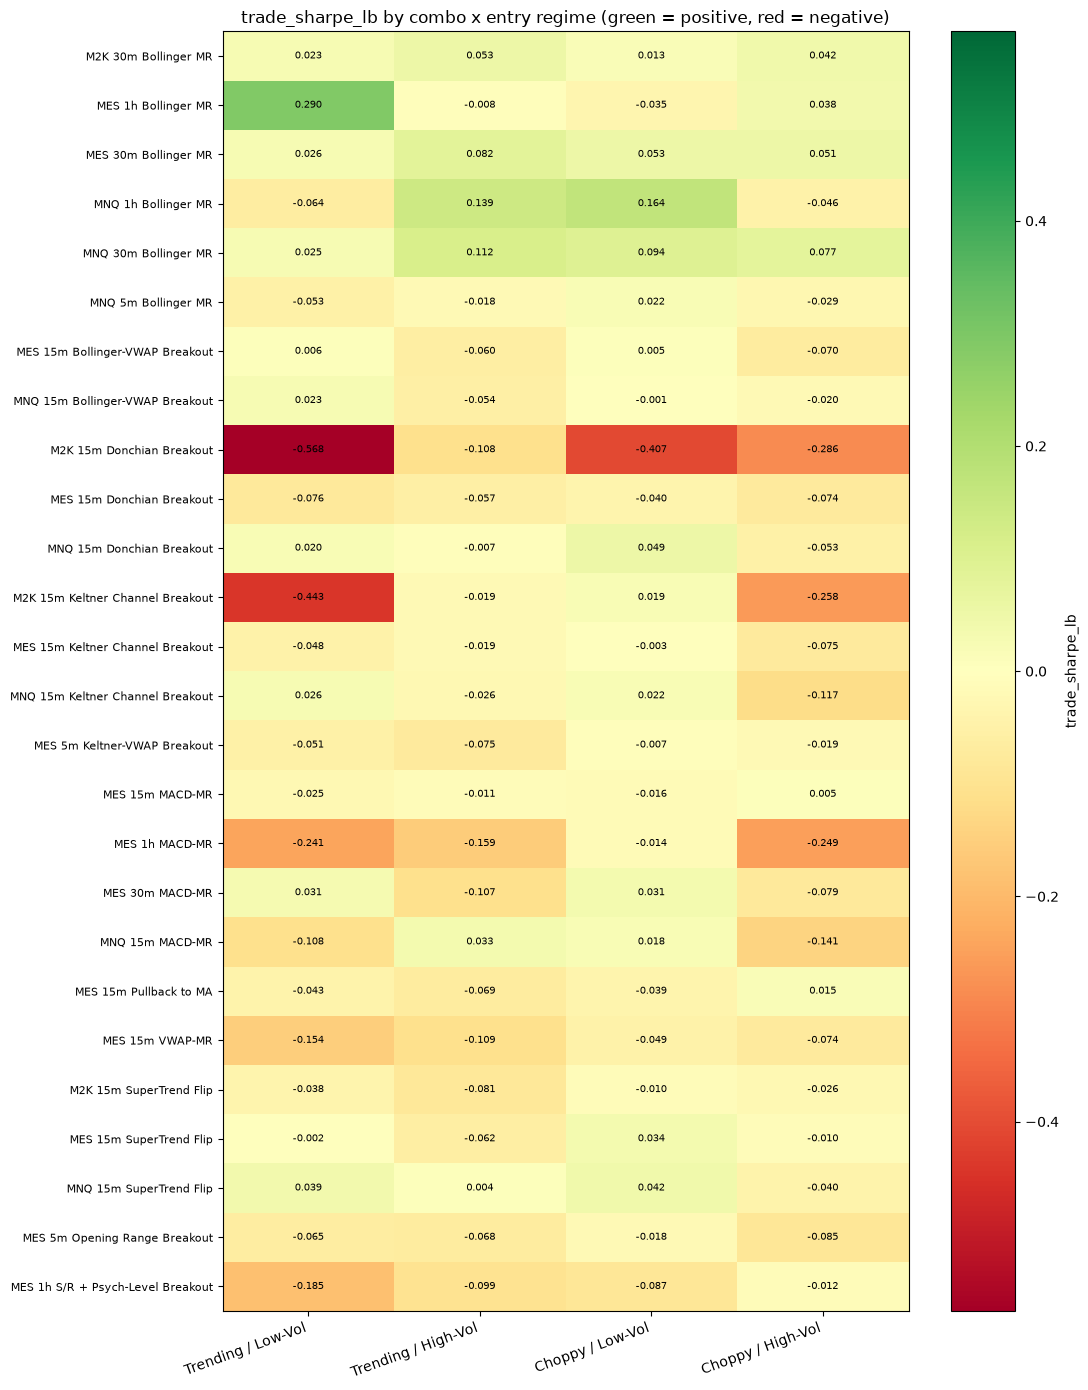

In [9]:
heatmap_data = pd.DataFrame({
    name: regime_tables[name]["trade_sharpe_lb"] for name in COMBO_DEFS
}).T.loc[list(COMBO_DEFS.keys()), REGIME_ORDER]

fig, ax = plt.subplots(figsize=(11, 14))
values = heatmap_data.values.astype(float)
vmax = np.nanmax(np.abs(values[~np.isnan(values)])) if np.isfinite(values).any() else 1.0
im = ax.imshow(values, cmap="RdYlGn", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(heatmap_data.columns)), labels=heatmap_data.columns, rotation=20, ha="right")
ax.set_yticks(range(len(heatmap_data.index)), labels=heatmap_data.index, fontsize=8)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, ax=ax, label="trade_sharpe_lb")
ax.set_title("trade_sharpe_lb by combo x entry regime (green = positive, red = negative)")
fig.tight_layout()
plt.show()

## Testing the specific hypotheses: dip behavior by mechanism

The user's hypothesis: Keltner Channel Breakout and SuperTrend Flip *follow*
market dips (drawdown tracks the dip down); Donchian Breakout does the
*opposite* (performs better during dips); Bollinger Mean Reversion doesn't
care about dips either way. "Dips" in this regime scheme are best
approximated by **Trending / High-Vol** (a strong directional move with
elevated realized vol -- covers both the 2020 COVID crash and 2022 bear
market) versus the calmer **Trending / Low-Vol** and **Choppy** regimes.

In [10]:
mechanism_map = {
    "Donchian Breakout": [n for n in COMBO_DEFS if "Donchian Breakout" in n],
    "Keltner Channel Breakout": [n for n in COMBO_DEFS if "Keltner Channel Breakout" in n],
    "SuperTrend Flip": [n for n in COMBO_DEFS if "SuperTrend Flip" in n],
    "Bollinger MR": [n for n in COMBO_DEFS if "Bollinger MR" in n],
}

dip_rows = []
for mechanism, names in mechanism_map.items():
    for name in names:
        table = regime_tables[name]
        dip_rows.append({
            "mechanism": mechanism, "combo": name,
            "Trending/High-Vol (dip proxy) lb": table.loc["Trending / High-Vol", "trade_sharpe_lb"],
            "Trending/Low-Vol lb": table.loc["Trending / Low-Vol", "trade_sharpe_lb"],
            "Choppy/High-Vol lb": table.loc["Choppy / High-Vol", "trade_sharpe_lb"],
            "Choppy/Low-Vol lb": table.loc["Choppy / Low-Vol", "trade_sharpe_lb"],
        })

dip_df = pd.DataFrame(dip_rows).set_index(["mechanism", "combo"])
print(dip_df.to_string())

                                                           Trending/High-Vol (dip proxy) lb  Trending/Low-Vol lb  Choppy/High-Vol lb  Choppy/Low-Vol lb
mechanism                combo                                                                                                                         
Donchian Breakout        M2K 15m Donchian Breakout                                -0.107783            -0.568264           -0.286379          -0.407463
                         MES 15m Donchian Breakout                                -0.057498            -0.075934           -0.074238          -0.039827
                         MNQ 15m Donchian Breakout                                -0.006506             0.020293           -0.053025           0.049470
Keltner Channel Breakout M2K 15m Keltner Channel Breakout                         -0.019101            -0.443274           -0.257528           0.019203
                         MES 15m Keltner Channel Breakout                         -0.018

## Refined dip test: Trending Down/High-Vol vs. Trending Up/High-Vol

With direction split out, **Trending Down / High-Vol is the precise dip
proxy** (a real crash, not a crash-or-melt-up label) -- and **Trending Up /
High-Vol** (a violent rally) is now available as a contrast. If a
mechanism's high-vol sensitivity found above is really about *direction*
(hurt by crashes specifically) rather than just *volatility* (hurt by any
violent move), the two should look different. If they look similar, the
mechanism is genuinely direction-blind and the earlier high-vol framing was
already the right read.

In [11]:
def regime_breakdown_directional(trades_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for regime in REGIME_ORDER_DIRECTIONAL:
        group = trades_df[trades_df["regime_directional"] == regime] if len(trades_df) else trades_df
        pnls = group["pnl"].to_numpy() if len(trades_df) else np.array([])
        n = len(pnls)
        wins = (pnls > 0).sum()
        win_rate = (wins / n * 100) if n else float("nan")
        gross_win = pnls[pnls > 0].sum()
        gross_loss = -pnls[pnls < 0].sum()
        profit_factor = (gross_win / gross_loss) if gross_loss > 0 else float("nan")
        sr, sr_lb, _ = trade_sharpe_lb(pnls) if n >= 2 else (float("nan"), float("nan"), n)
        rows.append({
            "regime": regime, "trades": n, "win_rate_percent": win_rate,
            "profit_factor": profit_factor, "sum_pnl_percent": pnls.sum() * 100 if n else 0.0,
            "trade_sharpe": sr, "trade_sharpe_lb": sr_lb,
        })
    return pd.DataFrame(rows).set_index("regime")


directional_tables = {name: regime_breakdown_directional(df) for name, df in combo_trade_dfs.items()}

dip_directional_rows = []
for mechanism, names in mechanism_map.items():
    for name in names:
        table = directional_tables[name]
        dip_directional_rows.append({
            "mechanism": mechanism, "combo": name,
            "Trending Down/High-Vol (crash) lb": table.loc["Trending Down / High-Vol", "trade_sharpe_lb"],
            "Trending Up/High-Vol (melt-up) lb": table.loc["Trending Up / High-Vol", "trade_sharpe_lb"],
            "Trending Down/Low-Vol lb": table.loc["Trending Down / Low-Vol", "trade_sharpe_lb"],
            "Trending Up/Low-Vol lb": table.loc["Trending Up / Low-Vol", "trade_sharpe_lb"],
            "crash trades": int(table.loc["Trending Down / High-Vol", "trades"]),
            "melt-up trades": int(table.loc["Trending Up / High-Vol", "trades"]),
        })

dip_directional_df = pd.DataFrame(dip_directional_rows).set_index(["mechanism", "combo"])
print(dip_directional_df.to_string())

                                                           Trending Down/High-Vol (crash) lb  Trending Up/High-Vol (melt-up) lb  Trending Down/Low-Vol lb  Trending Up/Low-Vol lb  crash trades  melt-up trades
mechanism                combo                                                                                                                                                                                 
Donchian Breakout        M2K 15m Donchian Breakout                                 -0.112942                          -0.713426                 -0.647374               -0.885061            25               5
                         MES 15m Donchian Breakout                                 -0.052623                          -0.434457                 -0.123801               -0.160224           197              25
                         MNQ 15m Donchian Breakout                                 -0.044196                           0.007525                 -0.068720               

## Findings

**All 26 combos ran cleanly (0 unmatched-regime trades anywhere).** Two
patterns come out clearly; the user's specific dip hypothesis is partially
right but the regime scheme used here can't fully test it as stated -- see
the caveat below.

### 1. Bollinger MR's regime-agnostic positivity is real, but it's a
property of the 30-minute interval specifically -- not of the mechanism

The three **walk-forward-confirmed** Bollinger MR combos (MES 30m, MNQ 30m,
and now M2K 30m too) are positive in **all 12 of 12** (3 symbols x 4
regimes) `trade_sharpe_lb` cells -- the cleanest, most uniform result in
this entire notebook. That extends the original 6-sleeve finding to a third
symbol.

But the **never-walk-forward-confirmed** Bollinger MR variants at other
intervals break this pattern: MNQ 5m has 3/4 regimes negative, MNQ 1h has
2/4 negative, MES 1h has 2/4 negative. So "Bollinger MR doesn't care about
regime" is really "Bollinger MR *at 30 minutes* doesn't care about regime"
-- consistent with 30m already being this program's standout interval for
this mechanism on independent (walk-forward) grounds, not a new discovery.

### 2. Trend-following mechanisms are regime-sensitive, but not along the
"Trending vs Choppy" axis intuition suggests -- along the vol axis instead

Across Donchian / Keltner / SuperTrend (9 symbol-combos total), the single
**best** regime on 5 of 9 is **Choppy / Low-Vol** -- calm grinding chop, not
a strong trend. That already complicates the simple "trend-followers need
trending markets" story motivating this analysis.

**Where the user's specific hypothesis holds up**: Keltner and SuperTrend's
**worst** regime, on 2 of 3 symbols each, is a **high-vol** one --
Choppy/High-Vol for Keltner (MES -0.075, MNQ -0.117), Trending/High-Vol for
SuperTrend (M2K -0.081, MES -0.062). Violent moves -- not "trend" per se --
are what hurts these two mechanisms; that's consistent with the stop-and-
reverse (SuperTrend) and squeeze-breakout (Keltner) constructions both being
prone to whipsaw when volatility spikes, regardless of which direction the
market ultimately goes.

**Donchian leans the opposite way on 2 of 3 symbols (M2K, MES)**: its worst
regime is a **low-vol** one (Trending/Low-Vol for both), and it's
relatively *least bad* in Trending/High-Vol -- the same regime that hurts
Keltner/SuperTrend most. MNQ Donchian doesn't fit this pattern (worst is
Choppy/High-Vol, +0.049 in Trending/High-Vol is merely its second-best
regime) -- so it's a real but not universal lean, present on 2/3 symbols,
in the direction the user described (Donchian tolerating or even preferring
violent conditions that hurt the other two trend-followers).

| mechanism | worst regime pattern | symbols supporting it |
|---|---|---|
| SuperTrend Flip | high-vol regime worst | M2K, MES (2/3) |
| Keltner Channel Breakout | Choppy/High-Vol worst | MES, MNQ (2/3) |
| Donchian Breakout | low-vol regime worst, high-vol relatively tolerated | M2K, MES (2/3) |

### Important caveat: this regime scheme can't fully test "performs better
*during a dip*" as literally stated

ADX + realized-vol percentile is **direction-agnostic** -- "Trending /
High-Vol" bundles a violent crash (2020, 2022) together with a violent
melt-up (2021) into the same label. So what's shown here is really
"sensitivity to violent/volatile conditions," which is close to but not
identical to "sensitivity to downward dips specifically." A sharper test
of the user's exact hypothesis would cross regime with the *sign* of the
trailing return (e.g. 20-day return negative vs. positive) -- not done
here, flagged as the natural next refinement if this distinction matters
enough to pursue further.

### Sample-size caveat

Splitting trades 4 ways by daily regime shrinks per-cell N a lot,
especially for M2K (lowest trade counts across the board -- e.g. Donchian's
regime cells range n=16 to n=30). M2K's Donchian/Keltner numbers in
particular should be read as suggestive, not reliable -- consistent with
M2K's generally noisy, under-powered standing throughout this program.

### Bottom line

This is descriptive, not a new trading rule -- consistent with the
walk-forward finding that a fitted regime-*gate* adds no real edge (see the
combined-portfolio walk-forward writeup). What's genuinely new here: each
mechanism does have a real, mechanism-specific (not just symbol-specific)
regime fingerprint, and it partially -- not fully -- matches the intuition
that motivated this whole line of work: Keltner and SuperTrend are hurt by
volatility spikes more than by "chop" per se, while Donchian tolerates (and
on 2/3 symbols, relatively prefers) the same volatile conditions.

---

## Update: directional split (+DI vs -DI) -- this changes the read

Added a 6-regime scheme (`compute_regime_directional`) that splits Trending
into Trending Up / Trending Down via +DI vs -DI, the same directional-
movement components ADX is built from. **Trending Down/High-Vol is now the
precise crash proxy; Trending Up/High-Vol is the precise melt-up proxy** --
replacing the old direction-agnostic "Trending/High-Vol" bucket that
conflated both.

**Regime frequency confirms the well-known volatility asymmetry**: across
all 3 symbols, Trending Down/High-Vol (283-354 days) is roughly 2-3x more
common than Trending Up/High-Vol (92-153 days) -- crashes generate more
realized vol than rallies of comparable size, so "big up move + high vol"
is intrinsically the rarer regime in this dataset. This alone means
melt-up-regime trade counts are small everywhere (14-153 per combo, vs.
25-354 for crash) -- read the melt-up numbers as suggestive, not solid.

### The finding that changes the earlier read: melt-ups, not crashes, are
what hurts the trend-followers

For all three long-only trend-following mechanisms, **Trending Up/High-Vol
(melt-up) has a lower `trade_sharpe_lb` than Trending Down/High-Vol
(crash)** -- consistently, not just on average:

| mechanism | crash lb range | melt-up lb range | melt-up worse on |
|---|---|---|---|
| SuperTrend Flip | -0.101 to +0.019 | -0.262 to -0.126 | 3/3 symbols |
| Keltner Channel Breakout | +0.003 to -0.045 | -0.517 to -0.160 | 3/3 symbols |
| Donchian Breakout | -0.113 to -0.044 | -0.713 to +0.008 | 2/3 symbols (MNQ ~flat) |

**This is the opposite of the original hypothesis as literally stated** --
these long-only strategies are relatively *less* bad during crash-labeled
conditions than during melt-up-labeled ones, not the other way around.

**Why this makes sense once you remember the regime label is trailing/
lagging, not real-time**: a long-only strategy only generates a "Trending
Down/High-Vol" entry when its own breakout/flip signal fires *against* what
the trailing daily indicator still calls a downtrend -- i.e. these are
early-reversal or bottom-fishing entries, which have a real chance of
catching genuine turns. A "Trending Up/High-Vol" entry, by contrast, is a
breakout attempt *during* a volatile, already-extended up-move -- exactly
the profile of a dead-cat bounce or short-squeeze inside a larger crisis
(2020's V-recovery, 2022's bear-market rallies), which is a classic
whipsaw trap for breakout/momentum systems. The mechanism-level pattern
(Keltner squeeze-breakout and SuperTrend stop-and-reverse, both entry
styles especially prone to false breakouts, show the *widest* crash-vs-
melt-up gap; Donchian, a slower/wider channel, shows the *narrowest*) is
consistent with this reversal-whipsaw explanation rather than a pure
"can't handle any big move" one.

**Bollinger MR shows the same crash-over-meltup lean, more mildly.** Its
two walk-forward-confirmed flagship combos (MES 30m, MNQ 30m) are both
positive in Trending Down/High-Vol (+0.072, +0.140) and both negative in
Trending Up/High-Vol (-0.089, -0.084) -- a real asymmetry inside what
looked like flat regime-agnostic positivity in the non-directional view,
though the swing is much smaller than the trend-followers' and the sign
isn't as pure across all 6 Bollinger MR combos (4/6 crash-positive, 2/6
melt-up-positive).

**Bottom line, revised**: the user's specific "follows the dip down"
framing doesn't hold for Keltner/SuperTrend once direction is actually
tested -- if anything these mechanisms are hurt more by volatile *up*
moves than by crashes. The original (correct, still-standing) finding is
narrower: violent moves of either sign are riskier for breakout/flip-style
trend-followers than calm ones, and among violent moves specifically, the
ones tangled up with reversals/short squeezes (which this dataset's high-
vol-up periods disproportionately are) are the worst of all. Small melt-up
sample sizes mean this should be treated as a real, mechanism-consistent
lean -- not a precise, load-bearing number.